In [ ]:
# 예술영화 일반영화 단어와, 장르 단어들 특성에 따른 WEAT score 계산 및 시각화 

In [1]:
import konlpy
import gensim
import sklearn
import seaborn

print(konlpy.__version__)
print(gensim.__version__)
print(sklearn.__version__)
print(seaborn.__version__)

0.6.0
4.4.0
1.9.0
0.13.2


In [ ]:
# 형태소 분석 (전체 장르 파일)

In [2]:
import os
from konlpy.tag import Okt
from tqdm.notebook import tqdm

okt = Okt()
data_dir = "/Users/sooah/weat/data/"

In [3]:
genre_txt = ['synopsis_SF.txt', 'synopsis_family.txt', 'synopsis_show.txt', 'synopsis_horror.txt', 'synopsis_etc.txt',
             'synopsis_documentary.txt', 'synopsis_drama.txt', 'synopsis_romance.txt', 'synopsis_musical.txt',
             'synopsis_mystery.txt', 'synopsis_crime.txt', 'synopsis_historical.txt', 'synopsis_western.txt',
             'synopsis_adult.txt', 'synopsis_thriller.txt', 'synopsis_animation.txt', 'synopsis_action.txt',
             'synopsis_adventure.txt', 'synopsis_war.txt', 'synopsis_comedy.txt', 'synopsis_fantasy.txt']
genre_name = ['SF', '가족', '공연', '공포(호러)', '기타', '다큐멘터리', '드라마', '멜로로맨스', '뮤지컬', '미스터리', '범죄', '사극', '서부극(웨스턴)',
         '성인물(에로)', '스릴러', '애니메이션', '액션', '어드벤처', '전쟁', '코미디', '판타지']

In [ ]:
# 토크나이저

In [4]:
def tokenize_file(filepath):
    tokenized = []
    with open(filepath, 'r') as file:
        lines = file.readlines()
    for line in tqdm(lines, desc=os.path.basename(filepath), leave=False):
        words = okt.pos(line, stem=True, norm=True)
        res = [w[0] for w in words if w[1] == 'Noun']
        tokenized.append(res)
    return tokenized

tokenized_by_genre = []
for fname in tqdm(genre_txt, desc="전체 장르 처리"):
    filepath = os.path.join(data_dir, fname)
    tokenized_by_genre.append(tokenize_file(filepath))

# art, gen도 별도로 처리 (target 단어셋용)
tokenized_art = tokenize_file(os.path.join(data_dir, 'synopsis_art.txt'))
tokenized_gen = tokenize_file(os.path.join(data_dir, 'synopsis_gen.txt'))

전체 장르 처리:   0%|          | 0/21 [00:00<?, ?it/s]

synopsis_SF.txt:   0%|          | 0/1023 [00:00<?, ?it/s]

synopsis_family.txt:   0%|          | 0/422 [00:00<?, ?it/s]

synopsis_show.txt:   0%|          | 0/346 [00:00<?, ?it/s]

synopsis_horror.txt:   0%|          | 0/3088 [00:00<?, ?it/s]

...

synopsis_war.txt:   0%|          | 0/387 [00:00<?, ?it/s]

synopsis_comedy.txt:   0%|          | 0/4635 [00:00<?, ?it/s]

synopsis_fantasy.txt:   0%|          | 0/801 [00:00<?, ?it/s]

synopsis_art.txt:   0%|          | 0/14435 [00:00<?, ?it/s]

synopsis_gen.txt:   0%|          | 0/48116 [00:00<?, ?it/s]

In [ ]:
# 임베딩 모델 만들기

In [5]:
from gensim.models import Word2Vec

all_tokenized = []
for tokens in tokenized_by_genre:
    all_tokenized.extend(tokens)
all_tokenized.extend(tokenized_art)
all_tokenized.extend(tokenized_gen)

model = Word2Vec(all_tokenized, vector_size=100, window=5, min_count=5, workers=4, sg=1)

print(model.wv.most_similar('사랑')) # 확인해보기

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


[('짊어지', 0.6499667763710022), ('파란만장', 0.6496625542640686), ('해피엔딩', 0.6458649635314941), ('종이학', 0.6350740790367126), ('토마슈', 0.6334118843078613), ('한적', 0.6312307715415955), ('만인', 0.630285382270813), ('윤복', 0.6274512410163879), ('네타', 0.6272247433662415), ('적신', 0.6241668462753296)]


In [ ]:
# 사랑 이외의 단어들로 확인해보기

In [6]:
for word in ['사랑', '전쟁', '가족', '살인']:
    print(word, '->', model.wv.most_similar(word)[:5])

사랑 -> [('짊어지', 0.6499667763710022), ('파란만장', 0.6496625542640686), ('해피엔딩', 0.6458649635314941), ('종이학', 0.6350740790367126), ('토마슈', 0.6334118843078613)]
전쟁 -> [('전투', 0.6489962339401245), ('선포', 0.6016280055046082), ('내전', 0.6015995740890503), ('주한', 0.5974067449569702), ('다이묘', 0.5972523093223572)]
가족 -> [('냉대', 0.5855720639228821), ('반려견', 0.574376106262207), ('친척', 0.5583896040916443), ('허울', 0.5515211224555969), ('이브라힘', 0.5418705344200134)]
살인 -> [('연쇄', 0.7586337327957153), ('연쇄살인', 0.7023642659187317), ('방화', 0.6886534094810486), ('범행', 0.6738572716712952), ('살해', 0.6649724841117859)]


In [ ]:
# Target/Attribute 단어셋

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

all_docs_tokens = tokenized_by_genre + [tokenized_art, tokenized_gen] # 총 22개 문서
all_names = genre_name + ['art', 'gen']

corpus = []
for doc_tokens in all_docs_tokens:
    words = [w for line in doc_tokens for w in line]
    corpus.append(' '.join(words))

vectorizer = TfidfVectorizer(min_df=3)
tfidf_matrix = vectorizer.fit_transform(corpus).toarray()  # (22, 단어수)
vocab = np.array(vectorizer.get_feature_names_out())

def get_distinctive_words(doc_idx, top_n=20):
    doc_tfidf = tfidf_matrix[doc_idx]
    other_mean = np.mean(np.delete(tfidf_matrix, doc_idx, axis=0), axis=0)
    distinctiveness = doc_tfidf - other_mean
    top_idx = distinctiveness.argsort()[::-1][:top_n]
    return vocab[top_idx].tolist()

art_idx = all_names.index('art') # art, gen = target 단어셋 (예술영화 vs 일반영화)
gen_idx = all_names.index('gen')

target_art = get_distinctive_words(art_idx, top_n=30)
target_gen = get_distinctive_words(gen_idx, top_n=30)

target_art = [w for w in target_art if w in model.wv][:15]
target_gen = [w for w in target_gen if w in model.wv][:15]

print("art:", target_art)
print("gen:", target_gen)

# 각 장르 = attribute 단어셋
attributes = []
for i, name in enumerate(genre_name):
    words = get_distinctive_words(i, top_n=30)
    words = [w for w in words if w in model.wv][:15]
    attributes.append(words)
    print(name, ":", words)

art: ['사랑', '시작', '그녀', '사람', '자신', '영화', '마음', '위해', '세상', '친구', '가족', '엄마', '남자', '과연', '서로']
gen: ['영화제', '국제', '그녀', '영화', '자신', '서울', '사람', '애니메이션', '남자', '친구', '이야기', '단편', '여자', '남편', '대한']
SF : ['지구', '인류', '인간', '미래', '우주', '로봇', '박사', '우주선', '외계', '행성', '위해', '세계', '스타크', '존재', '시스템']
가족 : ['아빠', '엄마', '가족', '낙타', '할머니', '동구', '아버지', '영화제', '아들', '학교', '친구', '미아', '펠리칸', '소년', '마을']
공연 : ['오페라', '실황', '토스카', '사랑', '올레', '카바', '공연', '오텔로', '백작', '프레', '비바', '베르디', '왕자', '콘서트', '카르피']
공포(호러) : ['공포', '친구', '사건', '사람', '발견', '죽음', '악령', '좀비', '시작', '저주', '살해', '악몽', '일행', '살인', '의문']
기타 : ['영화제', '국제', '서울', '단편', '뉴미디어', '페스티벌', '아시아나', '독립', '이야기', '영화', '연출', '이미지', '상영작', '지하철', '부산']
다큐멘터리 : ['영화제', '다큐', '다큐멘터리', '영화', '국제', '감독', '우리', '대한', '이야기', '서울', '여성', '한국', '통해', '환경', '세계']
드라마 : ['영화제', '영화', '사랑', '그녀', '자신', '국제', '단편', '엄마', '남자', '사람', '서울', '이야기', '여자', '마음', '부문']
멜로로맨스 : ['그녀', '사랑', '남편', '섹스', '여자', '남자', '마음', '결혼', '부부', '관계', '서로', '유혹', '연애', '친구',

In [ ]:
# 결과
공연/뮤지컬: 토스카, 에스메랄다, 카바 등 오페라/뮤지컬 등장인물, 작품명이 섞여있음(시놉시스에 자주 등장하는 고유명사라 높게 나옴)
기타, 다큐멘터리, 드라마에 공통적으로 영화제가 상위권에 겹쳐서 나옴

In [ ]:
# weat_score 변수 저장

In [9]:
import numpy as np

def cos_sim(i, j):
    return np.dot(i, j.T) / (np.linalg.norm(i) * np.linalg.norm(j))

def s(w, A, B):
    c_a = np.array([cos_sim(w, a) for a in A])
    c_b = np.array([cos_sim(w, b) for b in B])
    return np.mean(c_a) - np.mean(c_b)

def weat_score(X, Y, A, B):
    s_X = np.array([s(x, A, B) for x in X])
    s_Y = np.array([s(y, A, B) for y in Y])
    return (np.mean(s_X) - np.mean(s_Y)) / np.std(np.concatenate([s_X, s_Y], axis=0))

In [ ]:
# WEAT score 계산 및 시각화 

In [10]:
import numpy as np

n = len(genre_name)  # 장르 21개
matrix = np.zeros((n, n))  # 결과를 담을 21x21 크기의 빈 행렬 생성 (0으로)

# target 단어셋을 실제 워드임베딩 벡터로 변환
# X = 예술영화(art) 대표 단어들의 벡터 모음
# Y = 일반영화(gen) 대표 단어들의 벡터 모음
X = np.array([model.wv[w] for w in target_art])
Y = np.array([model.wv[w] for w in target_gen])

for i in range(n): # 모든 장르 쌍(i, j)에 대해 WEAT score를 계산
    for j in range(n): # i=SF, j=가족 이라면 -> "SF 장르 단어들 vs 가족 장르 단어들" 사이에서
        if i == j: # 예술/일반 영화 개념이 얼마나 다르게 편향되어 연관되는지를 측정
            continue  # 같은 장르끼리는 비교할 필요 없으므로 건너뜀
        
        # attribute 단어셋(i장르, j장르)을 벡터로 변환
        A = np.array([model.wv[w] for w in attributes[i]])  # i번째 장르의 대표 단어 벡터들
        B = np.array([model.wv[w] for w in attributes[j]])  # j번째 장르의 대표 단어 벡터들
        
        matrix[i][j] = weat_score(X, Y, A, B)  # WEAT score 계산

In [ ]:
# 그래프 시각화

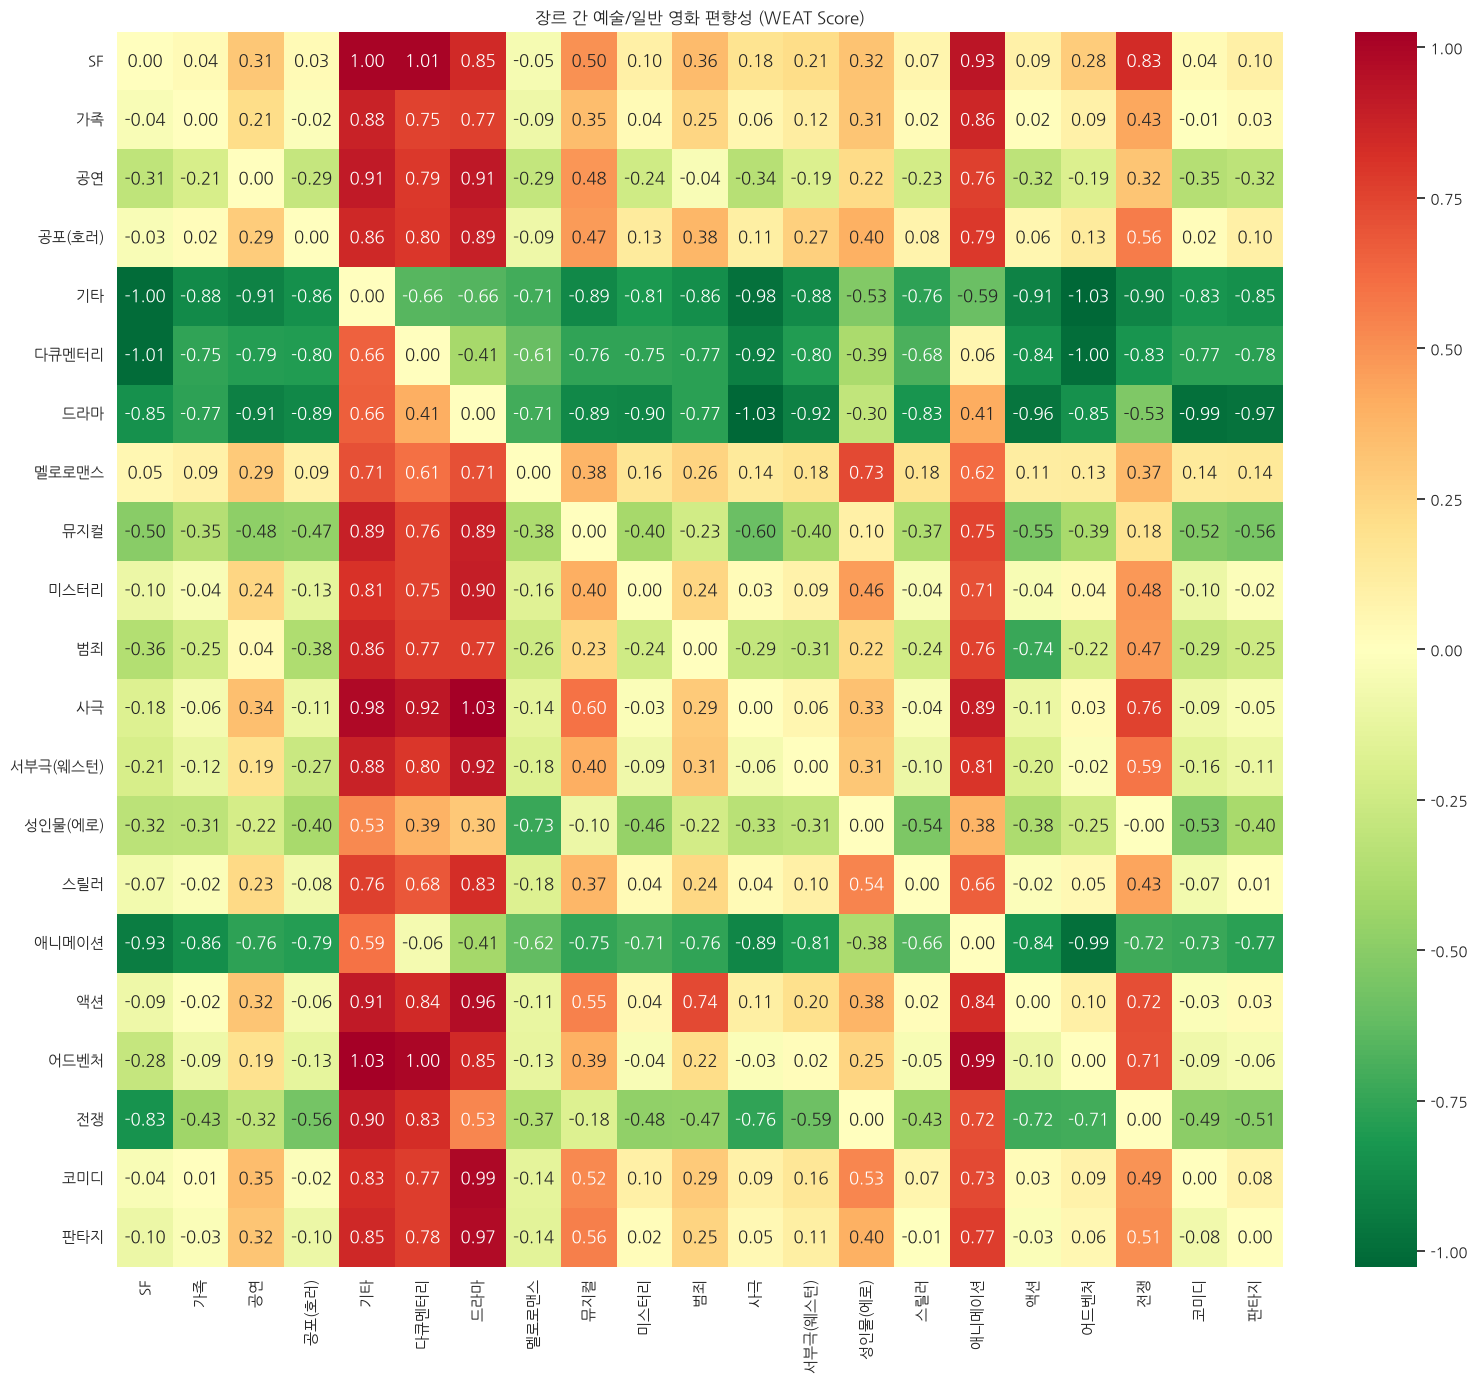

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(16, 14)) # 그래프 크기를 설정

sns.set(font='NanumGothic') # 나눔고딕 폰트 지정

plt.rcParams['axes.unicode_minus'] = False

sns.heatmap(matrix, xticklabels=genre_name, yticklabels=genre_name, # 히트맵 그리기
            annot=True, fmt='.2f', cmap='RdYlGn_r')

plt.title('장르 간 예술/일반 영화 편향성 (WEAT Score)')
plt.tight_layout() 
plt.show()

In [ ]:
# 결과
기타, 다큐멘터리, 드라마에 극단값이 포함됨
-> 편향적이라기보다는 세 장르가 다른 장르들의 특성과 다르기 떄문
예술 영화와 비슷한 값이라 극단으로 나옴 

SF, 가족, 공포, 사극, 서부극, 전쟁, 코미디, 판타지등은 특성이 뚜렷함
->오히려 신뢰할만함

In [12]:
meta_stopwords = ['영화제', '국제', '서울', '단편', '페스티벌', '부문', '상영작']

def get_distinctive_words(doc_idx, top_n=20):
    doc_tfidf = tfidf_matrix[doc_idx]
    other_mean = np.mean(np.delete(tfidf_matrix, doc_idx, axis=0), axis=0)
    distinctiveness = doc_tfidf - other_mean
    top_idx = distinctiveness.argsort()[::-1][:top_n]
    words = vocab[top_idx].tolist()
    words = [w for w in words if w not in meta_stopwords]  # 메타데이터성 단어 제거
    return words

In [13]:
# 1. target_art, target_gen 
target_art = get_distinctive_words(art_idx, top_n=30)
target_gen = get_distinctive_words(gen_idx, top_n=30)

target_art = [w for w in target_art if w in model.wv][:15]
target_gen = [w for w in target_gen if w in model.wv][:15]

print("art:", target_art)
print("gen:", target_gen)

art: ['사랑', '시작', '그녀', '사람', '자신', '영화', '마음', '위해', '세상', '친구', '가족', '엄마', '남자', '과연', '서로']
gen: ['그녀', '영화', '자신', '사람', '애니메이션', '남자', '친구', '이야기', '여자', '남편', '대한', '작품', '감독', '우리', '여성']


In [14]:
# 2. 장르별 attribute 단어셋
attributes = []
for i, name in enumerate(genre_name):
    words = get_distinctive_words(i, top_n=30)
    words = [w for w in words if w in model.wv][:15]
    attributes.append(words)
    print(name, ":", words)

SF : ['지구', '인류', '인간', '미래', '우주', '로봇', '박사', '우주선', '외계', '행성', '위해', '세계', '스타크', '존재', '시스템']
가족 : ['아빠', '엄마', '가족', '낙타', '할머니', '동구', '아버지', '아들', '학교', '친구', '미아', '펠리칸', '소년', '마을', '벤트']
공연 : ['오페라', '실황', '토스카', '사랑', '올레', '카바', '공연', '오텔로', '백작', '프레', '비바', '베르디', '왕자', '콘서트', '카르피']
공포(호러) : ['공포', '친구', '사건', '사람', '발견', '죽음', '악령', '좀비', '시작', '저주', '살해', '악몽', '일행', '살인', '의문']
기타 : ['뉴미디어', '아시아나', '독립', '이야기', '영화', '연출', '이미지', '지하철', '부산', '청소년', '메트로', '우리', '단편영화', '유럽', '작품']
다큐멘터리 : ['다큐', '다큐멘터리', '영화', '감독', '우리', '대한', '이야기', '여성', '한국', '통해', '환경', '세계', '노동자', '사회', '기록']
드라마 : ['영화', '사랑', '그녀', '자신', '엄마', '남자', '사람', '이야기', '여자', '마음', '아버지', '감독', '연출', '가족', '아들']
멜로로맨스 : ['그녀', '사랑', '남편', '섹스', '여자', '남자', '마음', '결혼', '부부', '관계', '서로', '유혹', '연애', '친구', '애인']
뮤지컬 : ['뮤지컬', '에스메랄다', '음악', '충무로', '모차르트', '카바', '토스카', '바흐', '모도', '사랑', '카르피', '팬텀', '데이비', '라훌', '크리스틴']
미스터리 : ['사건', '진실', '그녀', '사고', '민혁', '죽음', '미스터리', '기억', '살인', '시작', '현우', '발견', 

In [15]:
# 3. WEAT score 계산
n = len(genre_name)
matrix = np.zeros((n, n))

X = np.array([model.wv[w] for w in target_art])
Y = np.array([model.wv[w] for w in target_gen])

for i in range(n):
    for j in range(n):
        if i == j:
            continue
        A = np.array([model.wv[w] for w in attributes[i]])
        B = np.array([model.wv[w] for w in attributes[j]])
        matrix[i][j] = weat_score(X, Y, A, B)

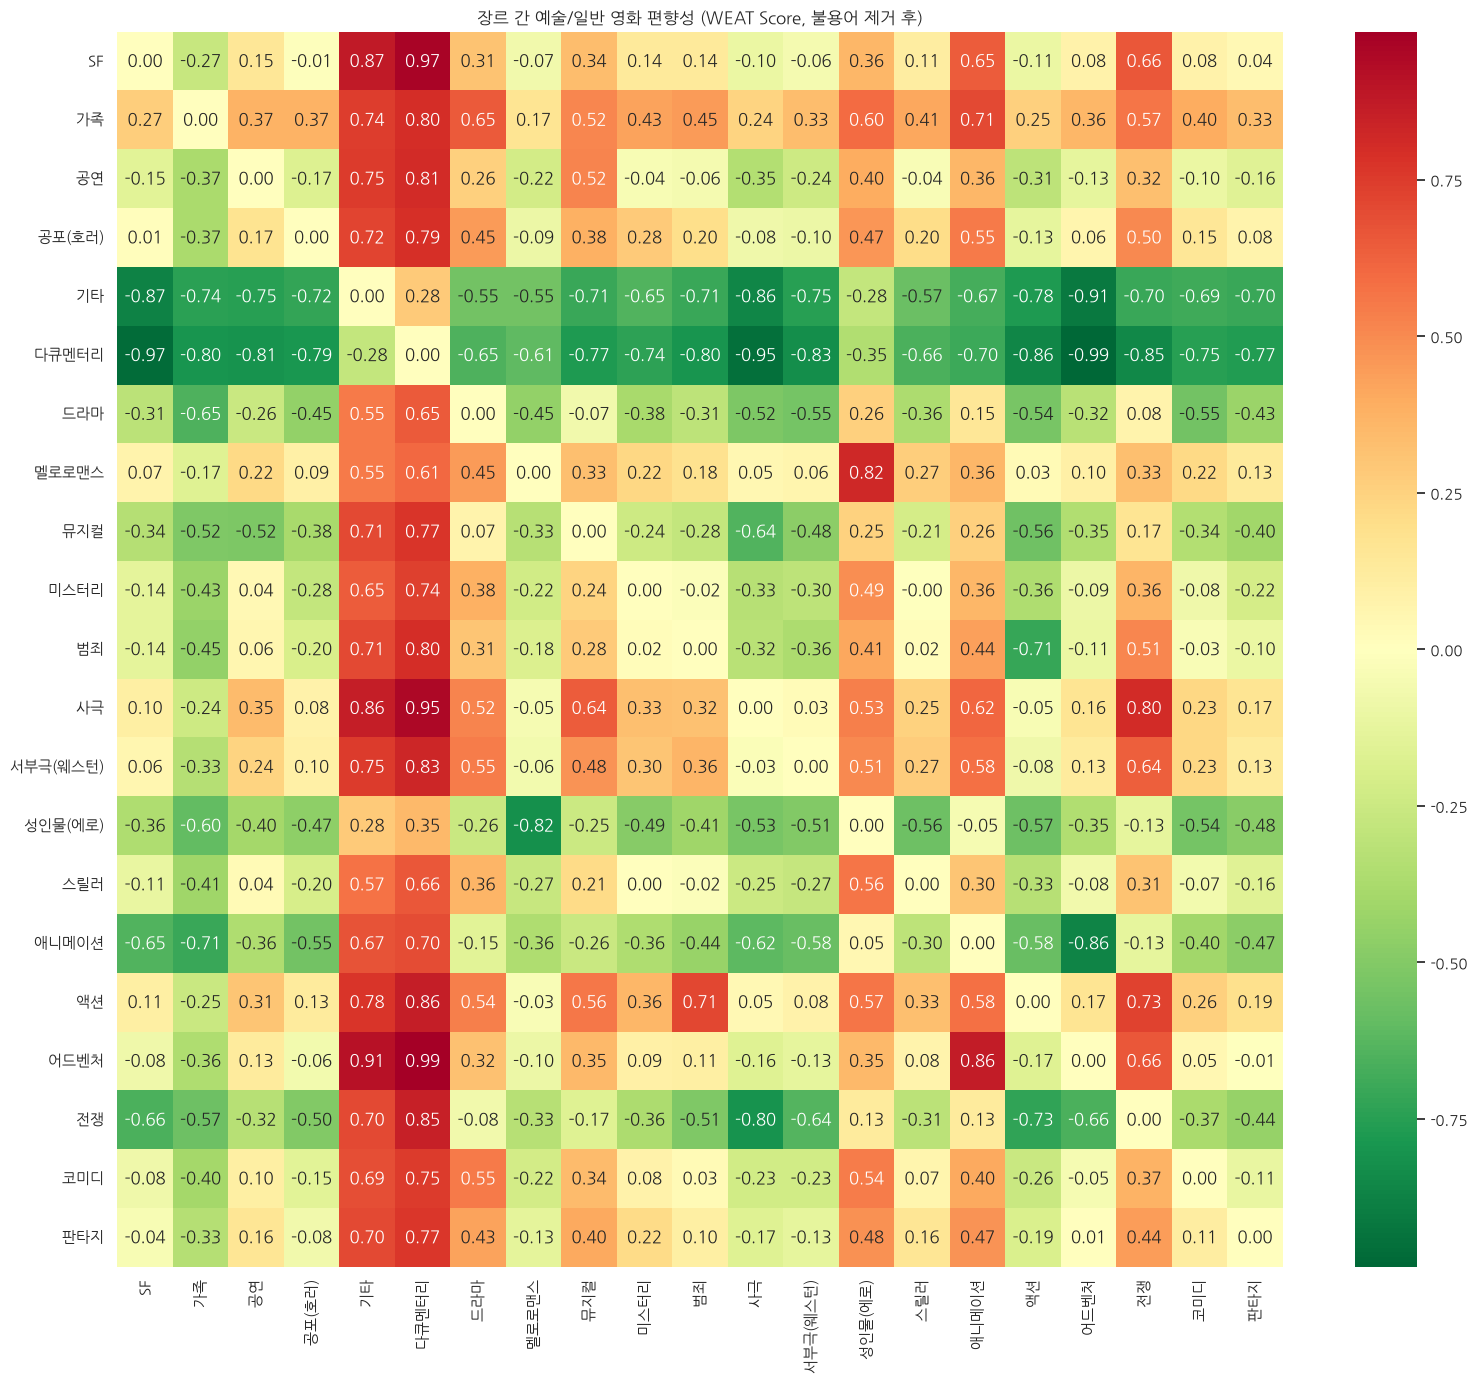

In [16]:
# 4. 히트맵 시각화
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 14))
sns.set(font='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

sns.heatmap(matrix, xticklabels=genre_name, yticklabels=genre_name,
            annot=True, fmt='.2f', cmap='RdYlGn_r')
plt.title('장르 간 예술/일반 영화 편향성 (WEAT Score, 불용어 제거 후)')
plt.tight_layout()
plt.show()

In [ ]:
# 결과
영화제, 국제, 단편 등 제거 후 평균값 비교
장르     필터 전  필터 후 
드라마	0.78	0.39	-50% (뚜렷한 개선)
기타	    0.83	0.67	-19% (다소 개선)
다큐멘터리	0.72	0.75	+4% (거의 그대로, 오히려 미세 증가)

드라마는 메타 단어 때문에 극단값이 나온 게 맞음
기타 또한 줄어들었음
다큐멘터리는 특성이 보여지지 않는 단어 제거해도 변화 미미함 오히려 증가함
->단어의 문제라기보다는 다큐멘터리 자체가 예술/일반 구분법과 맞지 않다. 

사극, 서부극, SF처럼 장르 특유의 소재 단어가 뚜렷한 장르들은 일반영화와 더 가깝고
성인물·전쟁·드라마는 예술영화가 더 가깝다.